**Objectif** : Analyser la latence réelle du modèle à partir des logs de monitoring (500 appels) pour l'étape 4 du projet OC_P6.

Ce notebook permet de :
- Charger le fichier de logs `predictions.jsonl` produit lors des appels de production simulés
- Détecter automatiquement la clé de temps enregistrée dans les logs
- Calculer les statistiques clés de latence (moyenne, médiane, p95, p99, min, max)
- Visualiser la distribution des temps de réponse

In [7]:
# ─── Cellule 2 : Imports et configuration ────────────────────────────────────
import json
import statistics
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style visuel
sns.set_style("whitegrid")
%matplotlib inline

# Chemin vers le fichier de logs de monitoring
LOG_FILE = Path("../logs/predictions.jsonl")
print(f"📂 Fichier analysé : {LOG_FILE}")

📂 Fichier analysé : ../logs/predictions.jsonl


In [8]:
# ─── Cellule 3 : Chargement des logs et création du DataFrame ────────────────

# Clés de temps candidates à détecter automatiquement dans les logs
CANDIDATE_KEYS = [
    "elapsed_ms", "duration", "prediction_time", "time_taken",
    "latence", "elapsed", "ms", "time", "execution_time_ms"
]

# Lecture du fichier JSONL ligne par ligne
records = []
with open(LOG_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:  # ignorer les lignes vides
            records.append(json.loads(line))

# Affichage des clés disponibles dans la première ligne du fichier
first_record = records[0]
print(f"🔑 Clés disponibles dans la première entrée : {list(first_record.keys())}")

# Détection automatique de la clé de temps parmi les candidats
detected_key = None
for key in CANDIDATE_KEYS:
    if key in first_record:
        detected_key = key
        break

# Vérification que la clé a bien été trouvée
if detected_key is None:
    raise KeyError(
        f"❌ Aucune clé de temps trouvée dans les logs.\n"
        f"   Clés présentes : {list(first_record.keys())}\n"
        f"   Clés recherchées : {CANDIDATE_KEYS}\n"
        f"   → Ajoutez la clé correcte dans CANDIDATE_KEYS."
    )

print(f"✅ Clé de temps détectée : '{detected_key}'")

# Construction de la liste des temps de réponse (en ms)
times = [record[detected_key] for record in records]

# Création du DataFrame principal
df = pd.DataFrame({"temps_ms": times})

print(f"📊 Nombre de prédictions chargées : {len(df)}")
df.head()

🔑 Clés disponibles dans la première entrée : ['timestamp', 'input_raw', 'input_features', 'output_proba', 'output_decision', 'execution_time_ms', 'error', 'model_version', 'threshold']
✅ Clé de temps détectée : 'execution_time_ms'
📊 Nombre de prédictions chargées : 515


,temps_ms
0,1273.9
1,65.8
2,64.9
3,64.7
4,65.1


In [9]:
# ─── Cellule 4 : Statistiques de latence ─────────────────────────────────────

# Calcul des métriques de latence
total_predictions = len(df)
temps_moyen  = df["temps_ms"].mean()
temps_median = statistics.median(df["temps_ms"])
temps_p95    = df["temps_ms"].quantile(0.95)
temps_p99    = df["temps_ms"].quantile(0.99)
temps_min    = df["temps_ms"].min()
temps_max    = df["temps_ms"].max()

# Affichage des statistiques avec emojis
print("═" * 45)
print("       📈 STATISTIQUES DE LATENCE")
print("═" * 45)
print(f"  🔢  Nombre total de prédictions : {total_predictions}")
print(f"  ⏱️   Temps moyen                : {temps_moyen:.2f} ms")
print(f"  📍  Médiane                     : {temps_median:.2f} ms")
print(f"  📊  Percentile 95 (p95)         : {temps_p95:.2f} ms")
print(f"  🔴  Percentile 99 (p99)         : {temps_p99:.2f} ms")
print(f"  ✅  Minimum                     : {temps_min:.2f} ms")
print(f"  ⚠️   Maximum                     : {temps_max:.2f} ms")
print("═" * 45)

═════════════════════════════════════════════
       📈 STATISTIQUES DE LATENCE
═════════════════════════════════════════════
  🔢  Nombre total de prédictions : 515
  ⏱️   Temps moyen                : 85.71 ms
  📍  Médiane                     : 66.50 ms
  📊  Percentile 95 (p95)         : 194.38 ms
  🔴  Percentile 99 (p99)         : 220.08 ms
  ✅  Minimum                     : 0.00 ms
  ⚠️   Maximum                     : 1273.90 ms
═════════════════════════════════════════════


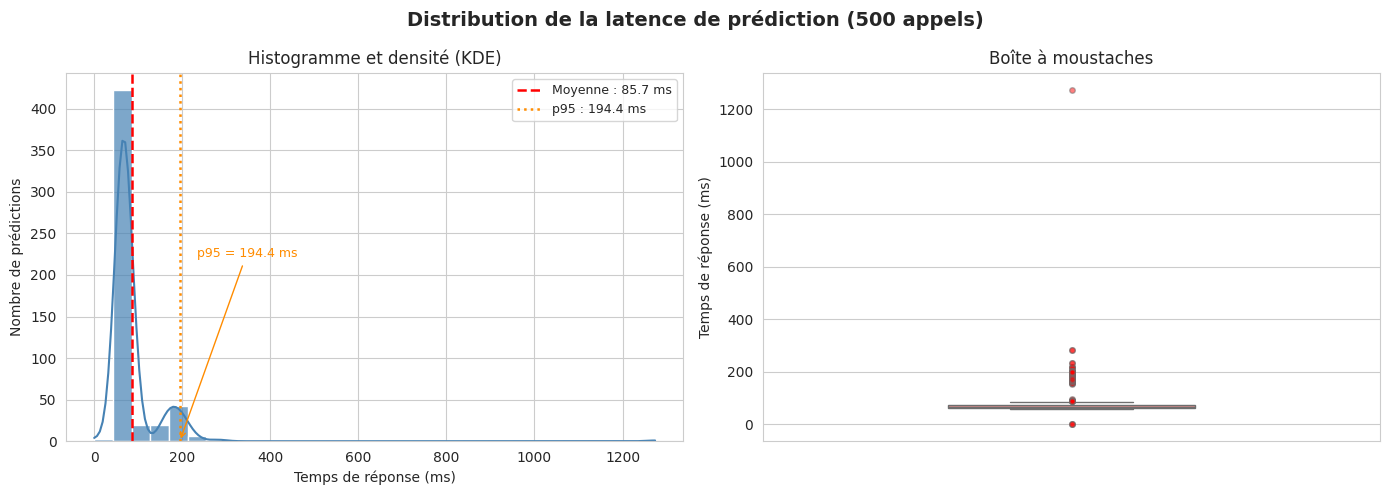

💾 Visualisation rendue avec succès pour 515 prédictions.


In [10]:
# ─── Cellule 5 : Visualisation de la distribution des latences ───────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de la latence de prédiction (500 appels)", fontsize=14, fontweight="bold")

# ── Subplot gauche : histogramme + KDE + ligne verticale moyenne ──────────────
ax1 = axes[0]
sns.histplot(
    data=df, x="temps_ms",
    kde=True,
    color="steelblue",
    alpha=0.7,
    bins=30,
    ax=ax1
)

# Ligne verticale rouge pour la moyenne
ax1.axvline(temps_moyen, color="red", linestyle="--", linewidth=1.8, label=f"Moyenne : {temps_moyen:.1f} ms")

# Annotation de la valeur p95
ax1.axvline(temps_p95, color="darkorange", linestyle=":", linewidth=1.8, label=f"p95 : {temps_p95:.1f} ms")
ax1.annotate(
    f"p95 = {temps_p95:.1f} ms",
    xy=(temps_p95, 0),
    xytext=(temps_p95 + (temps_max - temps_min) * 0.03, ax1.get_ylim()[1] * 0.5),
    fontsize=9,
    color="darkorange",
    arrowprops=dict(arrowstyle="->", color="darkorange")
)

ax1.set_title("Histogramme et densité (KDE)", fontsize=12)
ax1.set_xlabel("Temps de réponse (ms)", fontsize=10)
ax1.set_ylabel("Nombre de prédictions", fontsize=10)
ax1.legend(fontsize=9)

# ── Subplot droit : boîte à moustaches ───────────────────────────────────────
ax2 = axes[1]
sns.boxplot(
    data=df, y="temps_ms",
    color="lightcoral",
    width=0.4,
    flierprops=dict(marker="o", markerfacecolor="red", markersize=4, alpha=0.5),
    ax=ax2
)

ax2.set_title("Boîte à moustaches", fontsize=12)
ax2.set_ylabel("Temps de réponse (ms)", fontsize=10)
ax2.set_xlabel("")

fig.tight_layout()
plt.show()
print(f"💾 Visualisation rendue avec succès pour {total_predictions} prédictions.")